In [ ]:
import tensorflow as tf
import pandas as pd
import numpy as np
import time
from tensorflow.keras import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

In [14]:
df = pd.read_csv(r"C:\AMRITA\Final_Year_Project_zero_day_27\model_selection_zeroday_fyp_27\UNSW_NB15_training-set.csv")

print(df.shape)

df.head()

(82332, 45)


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,Normal,0


In [15]:
selected_features = [

    "dur",

    "proto",

    "service",

    "spkts",

    "dpkts",

    "sbytes",

    "dbytes",

    "rate",

    "sttl",

    "dttl",

    "sload",

    "dload",

    "sinpkt",

    "dinpkt",

    "sjit",

    "djit",

    "tcprtt",

    "synack",

    "ackdat",

    "ct_srv_src",

    "ct_state_ttl",

    "ct_dst_ltm",

    "ct_src_ltm",

    "ct_srv_dst"

]

df = df[selected_features]

df.head()

,dur,proto,service,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,...,sjit,djit,tcprtt,synack,ackdat,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_ltm,ct_srv_dst
0,0.000011,udp,-,2,0,496,0,90909.0902,254,0,...,0.0,0.0,0.0,0.0,0.0,2,2,1,1,2
1,0.000008,udp,-,2,0,1762,0,125000.0003,254,0,...,0.0,0.0,0.0,0.0,0.0,2,2,1,1,2
2,0.000005,udp,-,2,0,1068,0,200000.0051,254,0,...,0.0,0.0,0.0,0.0,0.0,3,2,1,1,3
3,0.000006,udp,-,2,0,900,0,166666.6608,254,0,...,0.0,0.0,0.0,0.0,0.0,3,2,2,2,3
4,0.000010,udp,-,2,0,2126,0,100000.0025,254,0,...,0.0,0.0,0.0,0.0,0.0,3,2,2,2,3


In [16]:
# Encode categorical columns

for col in ["proto","service"]:

    le = LabelEncoder()

    df[col] = le.fit_transform(df[col].astype(str))

# Replace infinities

df.replace([np.inf,-np.inf],np.nan,inplace=True)

# Fill missing values

df.fillna(df.median(numeric_only=True),inplace=True)

# Standardize

scaler = StandardScaler()

X = scaler.fit_transform(df)

print(X.shape)

(82332, 24)


In [17]:
print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])
print("Any NaN:", np.isnan(X).any())
print("Any infinity:", np.isinf(X).any())

Number of samples: 82332
Number of features: 24
Any NaN: False
Any infinity: False


In [18]:
input_dim = X.shape[1]

# Input
input_layer = Input(shape=(input_dim,))

# Encoder
encoded = Dense(16, activation="relu")(input_layer)
encoded = Dense(8, activation="relu")(encoded)

# Latent representation
latent = Dense(4, activation="linear", name="latent")(encoded)

# Decoder
decoded = Dense(8, activation="relu")(latent)
decoded = Dense(16, activation="relu")(decoded)
output_layer = Dense(input_dim, activation="linear")(decoded)

# Autoencoder
autoencoder = Model(
    inputs=input_layer,
    outputs=output_layer
)

autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

autoencoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 24)             │           408 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,164 (4.55 KB)

 Trainable params: 1,164 (4.55 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

start_time = time.time()

history = autoencoder.fit(
    X,
    X,
    epochs=50,
    batch_size=256,
    validation_split=0.1,
    shuffle=True,
    callbacks=[early_stop],
    verbose=1
)

autoencoder_training_time = time.time() - start_time

print(
    f"Autoencoder training time: "
    f"{autoencoder_training_time:.2f} seconds"
)

Epoch 1/50
290/290 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.6965 - val_loss: 0.7085
Epoch 2/50
290/290 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3649 - val_loss: 0.6073
Epoch 3/50
290/290 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2554 - val_loss: 0.5195
Epoch 4/50
290/290 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2144 - val_loss: 0.4725
Epoch 5/50
290/290 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1932 - val_loss: 0.4202
Epoch 6/50
290/290 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1799 - val_loss: 0.3954
Epoch 7/50
290/290 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1709 - val_loss: 0.3705
Epoch 8/50
290/290 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1608 - val_loss: 0.3510
Epoch 9/50
290/290 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1511 - val_loss: 0.3290
Epoch 10/50
290/290 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1421 - val_loss: 0.3210
Epoch 11/50
290/290 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1297 - val_loss: 0.3092
Epoch 12/50
290/290 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

Matplotlib is building the font cache; this may take a moment.


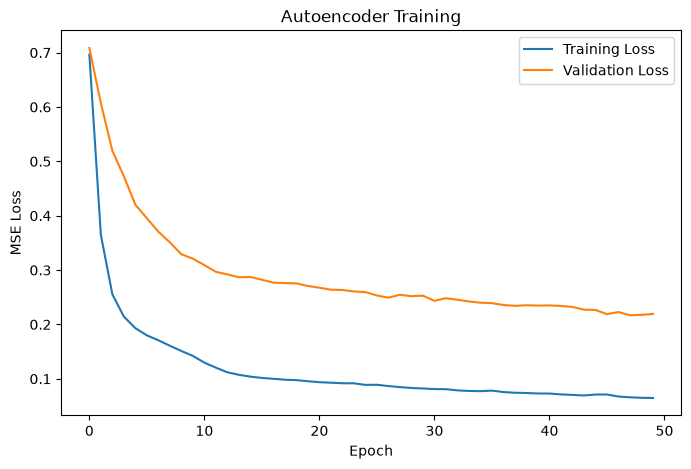

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Autoencoder Training")

plt.legend()
plt.show()

In [21]:
encoder = Model(
    inputs=autoencoder.input,
    outputs=autoencoder.get_layer("latent").output
)

start_time = time.time()

X_latent = encoder.predict(
    X,
    batch_size=256,
    verbose=1
)

latent_time = time.time() - start_time

print("Original shape:", X.shape)
print("Latent shape:", X_latent.shape)
print(f"Latent extraction time: {latent_time:.2f} seconds")

322/322 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Original shape: (82332, 24)
Latent shape: (82332, 4)
Latent extraction time: 1.04 seconds


In [22]:
from sklearn.cluster import KMeans

k = 10

start_time = time.time()

ae_kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

ae_labels = ae_kmeans.fit_predict(X_latent)

kmeans_time = time.time() - start_time

print("Clusters:", len(np.unique(ae_labels)))
print(f"K-Means time: {kmeans_time:.2f} seconds")

Clusters: 10
K-Means time: 1.58 seconds


In [23]:
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

silhouette = silhouette_score(
    X_latent,
    ae_labels
)

davies_bouldin = davies_bouldin_score(
    X_latent,
    ae_labels
)

calinski_harabasz = calinski_harabasz_score(
    X_latent,
    ae_labels
)

print("====================================")
print("Autoencoder + K-Means")
print("====================================")

print("Clusters:", len(np.unique(ae_labels)))
print("Silhouette:", silhouette)
print("Davies-Bouldin:", davies_bouldin)
print("Calinski-Harabasz:", calinski_harabasz)
print("AE Training Time:", autoencoder_training_time)
print("K-Means Time:", kmeans_time)
print("Total Time:", autoencoder_training_time + latent_time + kmeans_time)

Autoencoder + K-Means
Clusters: 10
Silhouette: 0.484982430934906
Davies-Bouldin: 0.8036630829996669
Calinski-Harabasz: 42448.438715629745
AE Training Time: 68.21191477775574
K-Means Time: 1.577988624572754
Total Time: 70.82634663581848


In [24]:
input_dim = X.shape[1]

input_layer = Input(shape=(input_dim,))

x = Dense(16, activation="relu")(input_layer)
x = Dense(8, activation="relu")(x)

latent = Dense(4, activation="linear", name="latent")(x)

encoder = Model(
    inputs=input_layer,
    outputs=latent
)

encoder.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 4)              │            36 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 572 (2.23 KB)

 Trainable params: 572 (2.23 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
# Generate initial latent representation
X_latent_dec = encoder.predict(
    X,
    batch_size=256,
    verbose=0
)

# Initial number of clusters
n_clusters = 10

kmeans_init = KMeans(
    n_clusters=n_clusters,
    random_state=42,
    n_init=10
)

initial_labels = kmeans_init.fit_predict(X_latent_dec)

cluster_centers = kmeans_init.cluster_centers_

print("Initial latent shape:", X_latent_dec.shape)
print("Initial clusters:", n_clusters)

Initial latent shape: (82332, 4)
Initial clusters: 10


In [26]:
class ClusteringLayer(tf.keras.layers.Layer):

    def __init__(self, n_clusters, alpha=1.0, **kwargs):
        super().__init__(**kwargs)

        self.n_clusters = n_clusters
        self.alpha = alpha

    def build(self, input_shape):

        input_dim = int(input_shape[-1])

        self.clusters = self.add_weight(
            shape=(self.n_clusters, input_dim),
            initializer="glorot_uniform",
            name="cluster_centers"
        )

        super().build(input_shape)

    def call(self, inputs):

        q = 1.0 / (
            1.0 +
            tf.reduce_sum(
                tf.square(
                    tf.expand_dims(inputs, 1)
                    - self.clusters
                ),
                axis=2
            ) / self.alpha
        )

        q = tf.pow(q, (self.alpha + 1.0) / 2.0)

        q = q / tf.reduce_sum(
            q,
            axis=1,
            keepdims=True
        )

        return q

In [29]:
from tensorflow.keras.optimizers import Adam
clustering_layer = ClusteringLayer(
    n_clusters=n_clusters,
    name="clustering"
)

cluster_output = clustering_layer(latent)

dec_model = Model(
    inputs=input_layer,
    outputs=cluster_output
)

# Initialize cluster centers using K-Means
clustering_layer.set_weights(
    [cluster_centers]
)

dec_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="kld"
)

dec_model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ clustering (ClusteringLayer)    │ (None, 10)             │            40 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 612 (2.39 KB)

 Trainable params: 612 (2.39 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
def target_distribution(q):

    weight = q ** 2 / np.sum(q, axis=0)

    return (
        weight.T /
        np.sum(weight, axis=1)
    ).T

In [31]:
start_time = time.time()

max_iterations = 1000
update_interval = 20

batch_size = 256

previous_labels = initial_labels.copy()

for iteration in range(max_iterations):

    if iteration % update_interval == 0:

        q = dec_model.predict(
            X,
            batch_size=batch_size,
            verbose=0
        )

        p = target_distribution(q)

        current_labels = np.argmax(q, axis=1)

        changed = np.sum(
            current_labels != previous_labels
        ) / len(current_labels)

        print(
            f"Iteration {iteration} | "
            f"Label change: {changed:.4f}"
        )

        previous_labels = current_labels.copy()

        # Stop if clusters have stabilized
        if iteration > 0 and changed < 0.001:
            print("Clusters stabilized.")
            break

    # Train one batch
    idx = np.random.choice(
        len(X),
        size=batch_size,
        replace=False
    )

    dec_model.train_on_batch(
        X[idx],
        p[idx]
    )

dec_training_time = time.time() - start_time

print(
    f"\nDEC training time: "
    f"{dec_training_time:.2f} seconds"
)

Iteration 0 | Label change: 0.0000
Iteration 20 | Label change: 0.0411
Iteration 40 | Label change: 0.0447
Iteration 60 | Label change: 0.0504
Iteration 80 | Label change: 0.0609
Iteration 100 | Label change: 0.0796
Iteration 120 | Label change: 0.0953
Iteration 140 | Label change: 0.0911
Iteration 160 | Label change: 0.0709
Iteration 180 | Label change: 0.0518
Iteration 200 | Label change: 0.0315
Iteration 220 | Label change: 0.0233
Iteration 240 | Label change: 0.0188
Iteration 260 | Label change: 0.0177
Iteration 280 | Label change: 0.0201
Iteration 300 | Label change: 0.0149
Iteration 320 | Label change: 0.0171
Iteration 340 | Label change: 0.0201
Iteration 360 | Label change: 0.0142
Iteration 380 | Label change: 0.0142
Iteration 400 | Label change: 0.0168
Iteration 420 | Label change: 0.0132
Iteration 440 | Label change: 0.0141
Iteration 460 | Label change: 0.0134
Iteration 480 | Label change: 0.0218
Iteration 500 | Label change: 0.0161
Iteration 520 | Label change: 0.0193
Iterati

In [32]:
q_final = dec_model.predict(
    X,
    batch_size=256,
    verbose=0
)

dec_labels = np.argmax(
    q_final,
    axis=1
)

print("Number of clusters:", len(np.unique(dec_labels)))

Number of clusters: 10


In [33]:
final_encoder = Model(
    inputs=dec_model.input,
    outputs=dec_model.get_layer("latent").output
)

X_dec_latent = final_encoder.predict(
    X,
    batch_size=256,
    verbose=0
)

print(X_dec_latent.shape)

(82332, 4)


In [34]:
dec_silhouette = silhouette_score(
    X_dec_latent,
    dec_labels
)

dec_db = davies_bouldin_score(
    X_dec_latent,
    dec_labels
)

dec_ch = calinski_harabasz_score(
    X_dec_latent,
    dec_labels
)

In [35]:
print("====================================")
print("DEC RESULTS")
print("====================================")

print("Clusters:", len(np.unique(dec_labels)))
print("Silhouette:", dec_silhouette)
print("Davies-Bouldin:", dec_db)
print("Calinski-Harabasz:", dec_ch)
print("Training Time:", dec_training_time)

DEC RESULTS
Clusters: 10
Silhouette: 0.6991626024246216
Davies-Bouldin: 0.4791543776116226
Calinski-Harabasz: 75241.66296234213
Training Time: 77.93424344062805


In [69]:
import numpy as np
import time
import tensorflow as tf

from tensorflow.keras import Model
from tensorflow.keras.layers import (
    Input,
    Dense,
    Lambda
)

from tensorflow.keras import backend as K

from sklearn.mixture import GaussianMixture

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

In [70]:
input_dim = X.shape[1]
latent_dim = 4

inputs = Input(shape=(input_dim,), name="vae_input")

# Encoder
x = Dense(16, activation="relu")(inputs)
x = Dense(8, activation="relu")(x)

# Mean and log variance
z_mean = Dense(
    latent_dim,
    name="z_mean"
)(x)

z_log_var = Dense(
    latent_dim,
    name="z_log_var"
)(x)

In [71]:
from keras import ops, random

class SamplingLayer(tf.keras.layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        clipped_log_var = ops.clip(z_log_var, -10.0, 10.0)
        epsilon = random.normal(
            shape=ops.shape(z_mean),
            dtype=z_mean.dtype
        )
        kl_loss = -0.5 * ops.mean(
            ops.sum(
                1 + clipped_log_var
                - ops.square(z_mean)
                - ops.exp(clipped_log_var),
                axis=1
            )
        )
        self.add_loss(kl_loss)
        return z_mean + ops.exp(0.5 * clipped_log_var) * epsilon


z = SamplingLayer(name="z")([z_mean, z_log_var])

In [72]:
decoder_input = Input(
    shape=(latent_dim,),
    name="decoder_input"
)

decoder_x = Dense(
    8,
    activation="relu"
)(decoder_input)

decoder_x = Dense(
    16,
    activation="relu"
)(decoder_x)

decoder_output = Dense(
    input_dim,
    activation="linear"
)(decoder_x)

decoder = Model(
    decoder_input,
    decoder_output,
    name="decoder"
)

decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ decoder_input (InputLayer)      │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 24)             │           408 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 592 (2.31 KB)

 Trainable params: 592 (2.31 KB)

 Non-trainable params: 0 (0.00 B)

In [73]:
vae_outputs = decoder(z)

vae = Model(
    inputs,
    vae_outputs,
    name="VAE"
)

print("Input shape:", inputs.shape)
print("VAE output shape:", vae_outputs.shape)

vae.summary()

Input shape: (None, 24)
VAE output shape: (None, 24)


Model: "VAE"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ vae_input           │ (None, 24)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_23 (Dense)    │ (None, 16)        │        400 │ vae_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_24 (Dense)    │ (None, 8)         │        136 │ dense_23[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 4)         │         36 │ dense_24[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 4)         │         36 │ dense_24[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z (SamplingLayer)   │ (None, 4)         │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder             │ (None, 24)        │        592 │ z[0][0]           │
│ (Functional)        │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,200 (4.69 KB)

 Trainable params: 1,200 (4.69 KB)

 Non-trainable params: 0 (0.00 B)

In [74]:
def vae_loss_fn(y_true, y_pred):
    return ops.mean(
        ops.sum(
            ops.square(ops.subtract(y_true, y_pred)),
            axis=1
        )
    )

vae.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4,
        clipnorm=1.0
    ),
    loss=vae_loss_fn
)

In [75]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="loss",
    patience=5,
    restore_best_weights=True
)

start_time = time.time()

vae_history = vae.fit(
    X,
    X,
    epochs=50,
    batch_size=256,
    validation_split=0.1,
    shuffle=True,
    callbacks=[early_stop],
    verbose=1
)

vae_training_time = time.time() - start_time

print(
    f"VAE training time: "
    f"{vae_training_time:.2f} seconds"
)

Epoch 1/50
290/290 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 37.4528 - val_loss: 54.3626
Epoch 2/50
290/290 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 29.6330 - val_loss: 52.7716
Epoch 3/50
290/290 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 28.3455 - val_loss: 46.6226
Epoch 4/50
290/290 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 26.7320 - val_loss: 38.1252
Epoch 5/50
290/290 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 24.0320 - val_loss: 33.3736
Epoch 6/50
290/290 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 22.6154 - val_loss: 30.8335
Epoch 7/50
290/290 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 21.3783 - val_loss: 29.0878
Epoch 8/50
290/290 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 20.2890 - val_loss: 28.2799
Epoch 9/50
290/290 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 19.6964 - val_loss: 27.2414
Epoch 10/50
290/290 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 19.2195 - val_loss: 26.3243
Epoch 11/50
290/290 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 18.8156 - val_loss: 25.5207
Epoch 12/50
290/290 ━━━━━━━━━━

In [76]:
encoder = Model(
    inputs,
    z_mean,
    name="VAE_encoder"
)

start_time = time.time()

X_vae_latent = encoder.predict(
    X,
    batch_size=256,
    verbose=1
)

if not np.isfinite(X_vae_latent).all():
    raise ValueError(
        "VAE produced non-finite latent values. "
        "Re-run the VAE build and training cells."
    )

latent_extraction_time = time.time() - start_time

print("Original shape:", X.shape)
print("VAE latent shape:", X_vae_latent.shape)
print(
    f"Latent extraction time: "
    f"{latent_extraction_time:.2f} seconds"
)

322/322 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Original shape: (82332, 24)
VAE latent shape: (82332, 4)
Latent extraction time: 1.01 seconds


In [77]:
n_components = 10

start_time = time.time()

vae_gmm = GaussianMixture(
    n_components=n_components,
    covariance_type="full",
    random_state=42,
    n_init=3
)

vae_gmm_labels = vae_gmm.fit_predict(
    X_vae_latent
)

gmm_time = time.time() - start_time

print(
    "GMM clusters:",
    len(np.unique(vae_gmm_labels))
)

print(
    f"GMM time: {gmm_time:.2f} seconds"
)

GMM clusters: 10
GMM time: 22.69 seconds


In [78]:
vae_gmm_silhouette = silhouette_score(
    X_vae_latent,
    vae_gmm_labels
)

vae_gmm_db = davies_bouldin_score(
    X_vae_latent,
    vae_gmm_labels
)

vae_gmm_ch = calinski_harabasz_score(
    X_vae_latent,
    vae_gmm_labels
)

total_time = (
    vae_training_time
    + latent_extraction_time
    + gmm_time
)

print("======================================")
print("VAE + GMM RESULTS")
print("======================================")

print(
    "Clusters:",
    len(np.unique(vae_gmm_labels))
)

print(
    "Silhouette:",
    vae_gmm_silhouette
)

print(
    "Davies-Bouldin:",
    vae_gmm_db
)

print(
    "Calinski-Harabasz:",
    vae_gmm_ch
)

print(
    "VAE Training Time:",
    vae_training_time
)

print(
    "GMM Time:",
    gmm_time
)

print(
    "Total Time:",
    total_time
)

VAE + GMM RESULTS
Clusters: 10
Silhouette: 0.08488938212394714
Davies-Bouldin: 2.5654416261105704
Calinski-Harabasz: 15650.850611514608
VAE Training Time: 76.89315223693848
GMM Time: 22.691607236862183
Total Time: 100.59711742401123


In [79]:
import pandas as pd

dl_results = pd.DataFrame({
    "Model": [
        "Autoencoder + K-Means",
        "DEC",
        "VAE + GMM"
    ],

    "Silhouette ↑": [
        silhouette,
        dec_silhouette,
        vae_gmm_silhouette
    ],

    "Davies-Bouldin ↓": [
        davies_bouldin,
        dec_db,
        vae_gmm_db
    ],

    "Calinski-Harabasz ↑": [
        calinski_harabasz,
        dec_ch,
        vae_gmm_ch
    ],

    "Training Time (s) ↓": [
        autoencoder_training_time + latent_time + kmeans_time,
        dec_training_time,
        total_time
    ]
})

# Round numerical values
dl_results = dl_results.round(4)

print("DEEP LEARNING MODEL COMPARISON")
print("=" * 80)

display(dl_results)

DEEP LEARNING MODEL COMPARISON


,Model,Silhouette ↑,Davies-Bouldin ↓,Calinski-Harabasz ↑,Training Time (s) ↓
0,Autoencoder + K-Means,0.4850,0.8037,42448.4387,70.8263
1,DEC,0.6992,0.4792,75241.6630,77.9342
2,VAE + GMM,0.0849,2.5654,15650.8506,100.5971
